<h1>Formation of Star Cluster from Gas Cloud Sonification</h1>

In [1]:
seed = 35 #set random number generator seed so can have conistent results
sonification_length = 20 #set sonification length
fps = 30 #frames per second
events_data_output_filename = "star_formation_events.csv"

<h2>Set Properties of Fake Data</h2>

In [2]:
number_stars = 100 #number of stars
time_min = 0. #minumum formation time
time_max = sonification_length #maximum formation time
time_width = 2. #width of formation times distribution
x_min = 0 #minumum x location of formation
x_max = 100 #maximum x location of formation
y_min = 0 #minumum y location of formation
y_max = 100  #maximum y location of formation
x_position_width = 13 #width of distribution in x
y_position_width = 13 #width of distribution in y

<h2>Code base start</h2>

In [3]:
#import packages
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import strauss
from statsmodels.distributions.empirical_distribution import ECDF
import csv

In [4]:
#Plotting parameters
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.linestyle'] = '--'
mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 15
mpl.rcParams['axes.labelweight'] = 2

mpl.rcParams['ytick.right'] = True
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 2
mpl.rcParams['ytick.labelsize'] = 12

mpl.rcParams['xtick.top'] = True
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['xtick.labelsize'] = 12

In [5]:
#Universal time array (for sonification and animation)
number_frames = fps*(time_max - time_min)
time_array = np.arange(time_min, time_max, 1/fps)

In [6]:
#Gaussian model for fitting distribution later
def gaus(X,C,X_mean,sigma):
    return C*np.exp(-(X-X_mean)**2/(2*sigma**2))

<h3>Create Fake Data</h3>

In [7]:
#Formation Times
np.random.seed(seed)
formation_times = np.random.randn(number_stars)*time_width + (time_max-time_min)/2.
formation_times.sort()

In [8]:
#Fit the distribution of formation times go can calculate the concurrent star formation rate
formation_times_hist, formation_times_bin_edges = np.histogram(formation_times)
n_bin_edges = len(formation_times_hist)
time_bin_values = np.zeros((n_bin_edges),dtype=float) 
for ii in range(n_bin_edges):
    time_bin_values[ii]=(formation_times_bin_edges[ii+1]+formation_times_bin_edges[ii])/2
mean_guess = (time_max-time_min)/2.                 
sigma_guess = time_width
param_optimised,param_covariance_matrix = curve_fit(gaus,time_bin_values,formation_times_hist,p0=[max(formation_times_hist),mean_guess,sigma_guess],maxfev=5000)

In [9]:
#Calculate star formation rate as a function of time
formation_times_fit = gaus(time_array,*param_optimised)
star_formation_rate_fit = formation_times_fit/time_array

C:\Users\ngc133\AppData\Local\Temp\ipykernel_28456\3211519304.py:3: RuntimeWarning: divide by zero encountered in divide
  star_formation_rate_fit = formation_times_fit/time_array


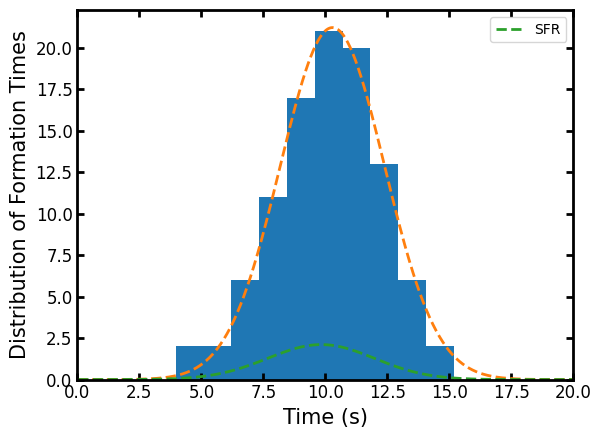

In [10]:
#Plot formation time distribution and star formation calculation (SFR)
fig, ax = plt.subplots()
ax.hist(formation_times)
ax.plot(time_array,formation_times_fit)
ax.plot(time_array,star_formation_rate_fit,label='SFR')
ax.set_xlim([time_min,time_max])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Distribution of Formation Times')
plt.legend()
plt.show()

<h3>Need to map on to the frames of the animation</h3>

In [11]:
#Map everything on to the time of the nearest frame in the animation
closest_time_indices = np.zeros(number_stars,dtype=int)
frame_matched_formation_time = np.zeros(number_stars,dtype=float)
current_star_formation_rate = np.zeros(number_stars,dtype=float) 
for x in range(number_stars):
    closest_time_indices[x] = (np.abs(time_array - formation_times[x])).argmin()
    frame_matched_formation_time[x] = time_array[closest_time_indices[x]]
    current_star_formation_rate[x] = star_formation_rate_fit[closest_time_indices[x]]

<h3> Calculate Data for the Gas Cloud Conversion into Stars (Reduction in volume)</h3>

In [12]:
#Use the culumative distribtion of formation times (inverted)
#This effective represents volume *not* converted to stars
e = ECDF(formation_times)
cumulative_formation = np.interp(time_array,e.x,e.y) #interpolate onto universal time array
#Adding an offset because in reality would have some gas cloud left at the end (don't want it to go to zero)
cloud_collapse = 1-cumulative_formation+0.2 #probably should set this as a parameter as star of code

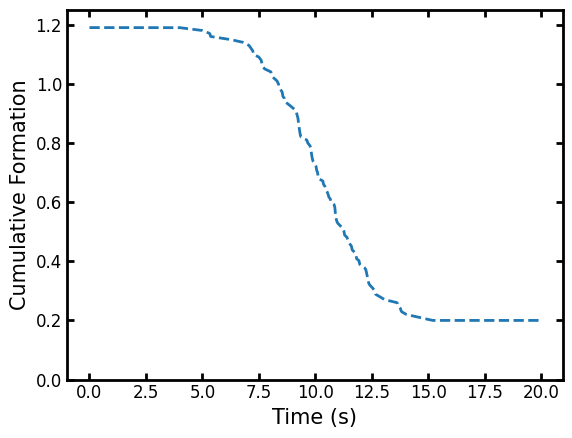

In [13]:
fig, ax = plt.subplots()
ax.plot(time_array,cloud_collapse)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Cumulative Formation')
ax.set_ylim([0,max(cloud_collapse)+0.05*max(cloud_collapse)])
plt.show()

<h3>Generate random positions for the location of the formed stars</h3>

In [14]:
x_positions = np.random.randn(number_stars)*x_position_width + (x_max-x_min)/2.
y_positions = np.random.randn(number_stars)*y_position_width + (y_max-y_min)/2.    

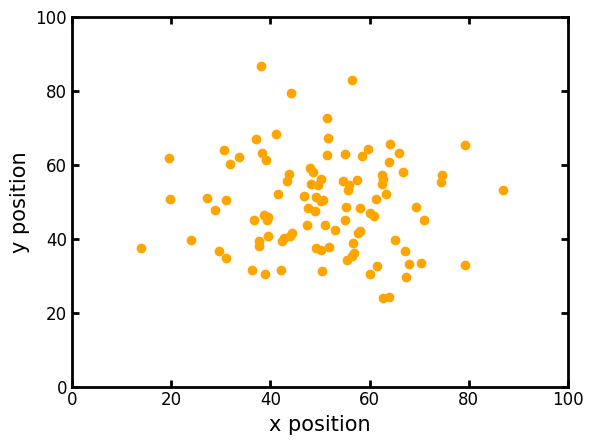

In [15]:
fig, ax = plt.subplots()
ax.plot(x_positions,y_positions,marker='o',linestyle='none',color="orange")
ax.set_xlabel('x position')
ax.set_ylabel('y position')
ax.set_xlim([x_min,x_max])
ax.set_ylim([y_min,y_max])
plt.show()

<h3>Generate Final Events Data for Sonification</h3>

Need to add a silent event at the begnning and end of the array for the event-based sonification (so the sonification goes from 0 seconds to the sonification length, and is not scaled to where only events exist). Set these to have zero SFR so can have zero volume.

In [17]:
formation_times = np.hstack([0,np.array(formation_times),sonification_length])
closest_time_indices = np.hstack([0,np.array(closest_time_indices),len(closest_time_indices)-1])
frame_matched_formation_time = np.hstack([0,np.array(frame_matched_formation_time),np.max(time_array)])
x_positions = np.hstack([np.min(x_positions),np.array(x_positions),np.max(x_positions)])
y_positions = np.hstack([0,np.array(y_positions),0])
current_star_formation_rate = np.hstack([0,np.array(current_star_formation_rate),0])

20


In [18]:
#Create Dictionary
fieldnames = ["iD","FormationTime","ClosestTimeIndice","FrameMatchedFormationTime","xPosition","yPosition","currentSFR"]
iDlist = np.arange(0,number_stars+2,1)
star_formation_events_data = [{
"iD" : v,
"FormationTime" : formation_times[i],
"ClosestTimeIndice": closest_time_indices[i], 
"FrameMatchedFormationTime": frame_matched_formation_time[i],     
"xPosition" : x_positions[i],
"yPosition" : y_positions[i],
"currentSFR" : current_star_formation_rate[i]
} for i,v in enumerate(iDlist)]                    

In [19]:
#Write to file
with open(events_data_output_filename, mode='w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()  # Write header row
    writer.writerows(star_formation_events_data)  # Write data rows

<h3>Make Sonification</h3>

<h4>Star Formation Events</h4>

Mappings:

**Event time** = formation_times

**Pitch** = current_star_formation_rate

**Volume** = current_star_formation_rate

**Azimuth (or Pan in STRAUSS V1.5)** = x_positions

In [20]:
# Stars Forming

from strauss.sonification import Sonification
from strauss.sources import Events, Objects
from strauss.score import Score
from strauss.generator import Sampler

generator = Sampler('Harp')
notes = [['F2', 'G2', 'C3', 'D3', 'F3', 'G3', 'C4', 'D4', 'F4', 'G4', 'C5', 'D5']]
length = 20
score = Score(notes, length)

# Rescale azimuth input between 0-1 for correct behaviour in STRAUSS
rescaled_x = (x_positions - np.min(x_positions)) / (np.max(x_positions) - np.min(x_positions))

# Add slight pitch variation to make same notes sound slighly different
pitch_jitter = np.random.normal(0, 0.01, len(x_positions))

# Mapping
data = {
    'time': formation_times,
    'pitch': current_star_formation_rate,
    'volume': current_star_formation_rate,
    'azimuth': rescaled_x,
    'polar': [0.5]*len(x_positions),
    'pitch_shift': pitch_jitter
}

m_lims = {
    'time': ('0%', '101%')
}

p_lims = {
    'time': (0, 1),
    'volume': (0.2, 1),
    'azimuth': (0.25, 0.75),
    'pitch_shift': (0,1)
}

sources = Events(data.keys())
sources.fromdict(data)
sources.apply_mapping_functions(map_lims=m_lims, param_lims=p_lims)

soni = Sonification(score, sources, generator, "stereo")
soni.render()
soni.save('stars_forming.wav')

Saved stars_forming.wav


In [21]:
# Cloud Synth
from strauss.sources import Objects
from strauss.generator import Synthesizer

generator = Synthesizer()
generator.load_preset('default')

generator.modify_preset({
    'oscillators': {
        'osc1': {
            'form': 'sine',
            'level': 1
        },
        'osc2': {
            'form': 'sine',
            'level': 0.2,
            'detune': 0.75
        }
    }
})

score = Score([['F2', 'C3', 'F3', 'C4']], length)

data = {
    'time_evo': [time_array]*4,
    'pitch': [0,1,2,3],
    'volume': [cloud_collapse]*4
}

m_lims = {
    'time_evo': ('0%', '100%')
}

p_lims = {
    'volume': (0.3, 1)
}

sources = Objects(data.keys())
sources.fromdict(data)
sources.apply_mapping_functions(map_lims=m_lims, param_lims=p_lims)

soni = Sonification(score, sources, generator, "mono")
soni.render()
soni.save('gas_chord.wav', master_volume=1)

Saved gas_chord.wav


0.23086458333333332
0.36665625


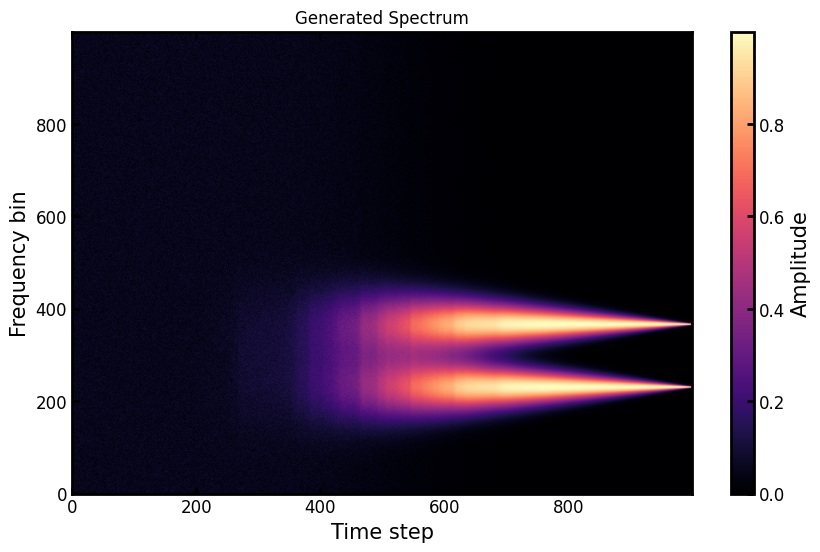

Saved spectrum_shift.wav


<Figure size 1800x1200 with 0 Axes>

In [33]:
# Spectraliser for gas cloud collapse

from strauss.generator import Spectralizer

n_freqs = 1000
n_time = 1000

# frequency axis (0 → 1 normalized)
freqs = np.linspace(0, 1, n_freqs)

# set limits and choose target frequencies
min_freq = 40
max_freq = 1000

# target frequencies
f1 = 261.63
f2 = 391.99

f1 = (f1 - min_freq) / (max_freq - min_freq)
print(f1)
f2 = (f2 - min_freq) / (max_freq - min_freq)
print(f2)

# width of peaks (shrinks over time)
max_width = 0.1
min_width = 0.001

spec_stack = np.zeros((n_freqs, n_time))

cloud_norm = (cloud_collapse - cloud_collapse.min()) / (cloud_collapse.max() - cloud_collapse.min())

# Stretch to match n_time using interpolation
cloud_interp = np.interp(
    np.linspace(0, 1, n_time),
    np.linspace(0, 1, len(cloud_collapse)),
    cloud_norm
)

# Build the evolution
for t in range(n_time):
    
    alpha = t / (n_time - 1) # For width narrowing
    noise_weight = cloud_interp[t]        # 1.0 → 0.0 driven by collapse data
    peak_weight  = 1 - cloud_interp[t]    # 0.0 → 1.0 (inverse)
    
    # start wide → end narrow
    width = max_width * (1 - alpha) + min_width * alpha
    
    # two Gaussian peaks
    peak1 = np.exp(-0.5 * ((freqs - f1) / width)**2)
    peak2 = np.exp(-0.5 * ((freqs - f2) / width)**2)
    
    peaks = peak1 + peak2
    
    # noise component (strong at start, fades out)
    noise = np.random.rand(n_freqs)
    
    spectrum = noise_weight*0.1 * noise + peak_weight * peaks
    
    spec_stack[:, t] = spectrum


# Plot
plt.figure(figsize=(10, 6))
plt.imshow(spec_stack, aspect='auto', origin='lower', cmap='magma')
plt.colorbar(label='Amplitude')
plt.xlabel('Time step')
plt.ylabel('Frequency bin')
plt.title('Generated Spectrum')
plt.show()


length = 20
score = Score([['A2']], length)

generator = Spectralizer()

generator.modify_preset({
    'min_freq': min_freq,
    'max_freq': max_freq,
    'regen_phases': True,
    'interpolation_type': 'preserve_power',
    'equal_loudness_normalisation': False
})

# set up spectrum
data = {'spectrum':[spec_stack.T], 'pitch':[1]}

# again, use maximal range for the mapped parameters
lims = {'spectrum': ('0%','100%')}

# set up source
sources = Events(data.keys())
sources.fromdict(data)
sources.apply_mapping_functions(map_lims=lims)

# render and play sonification!
soni = Sonification(score, sources, generator, 'stereo')
soni.render()
soni.notebook_display(show_waveform=0)
soni.save('spectrum_shift.wav')

